In [33]:
import pandas as pd

In [34]:
df = pd.read_csv('pima.csv',index_col=0)

In [35]:
df

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
1,6,148.0,72.0,35.0,NaN,33.6,0.627,50,pos
2,1,85.0,66.0,29.0,NaN,26.6,0.351,31,neg
3,8,183.0,64.0,NaN,NaN,23.3,0.672,32,pos
4,1,89.0,66.0,23.0,94.0,28.1,0.167,21,neg
5,0,137.0,40.0,35.0,168.0,43.1,2.288,33,pos
...,...,...,...,...,...,...,...,...,...
764,10,101.0,76.0,48.0,180.0,32.9,0.171,63,neg
765,2,122.0,70.0,27.0,NaN,36.8,0.340,27,neg
766,5,121.0,72.0,23.0,112.0,26.2,0.245,30,neg
767,1,126.0,60.0,NaN,NaN,30.1,0.349,47,pos


In [36]:
df.isna().any()

pregnant    False
glucose      True
pressure     True
triceps      True
insulin      True
mass         True
pedigree    False
age         False
diabetes    False
dtype: bool

In [37]:
df.describe()

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [38]:
df

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
1,6,148.0,72.0,35.0,NaN,33.6,0.627,50,pos
2,1,85.0,66.0,29.0,NaN,26.6,0.351,31,neg
3,8,183.0,64.0,NaN,NaN,23.3,0.672,32,pos
4,1,89.0,66.0,23.0,94.0,28.1,0.167,21,neg
5,0,137.0,40.0,35.0,168.0,43.1,2.288,33,pos
...,...,...,...,...,...,...,...,...,...
764,10,101.0,76.0,48.0,180.0,32.9,0.171,63,neg
765,2,122.0,70.0,27.0,NaN,36.8,0.340,27,neg
766,5,121.0,72.0,23.0,112.0,26.2,0.245,30,neg
767,1,126.0,60.0,NaN,NaN,30.1,0.349,47,pos


<Axes: xlabel='pregnant', ylabel='Density'>

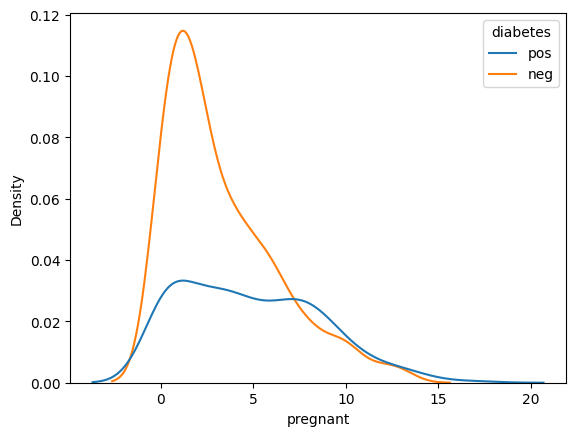

In [39]:
import seaborn as sns
sns.kdeplot(data=df,x="pregnant",hue="diabetes")

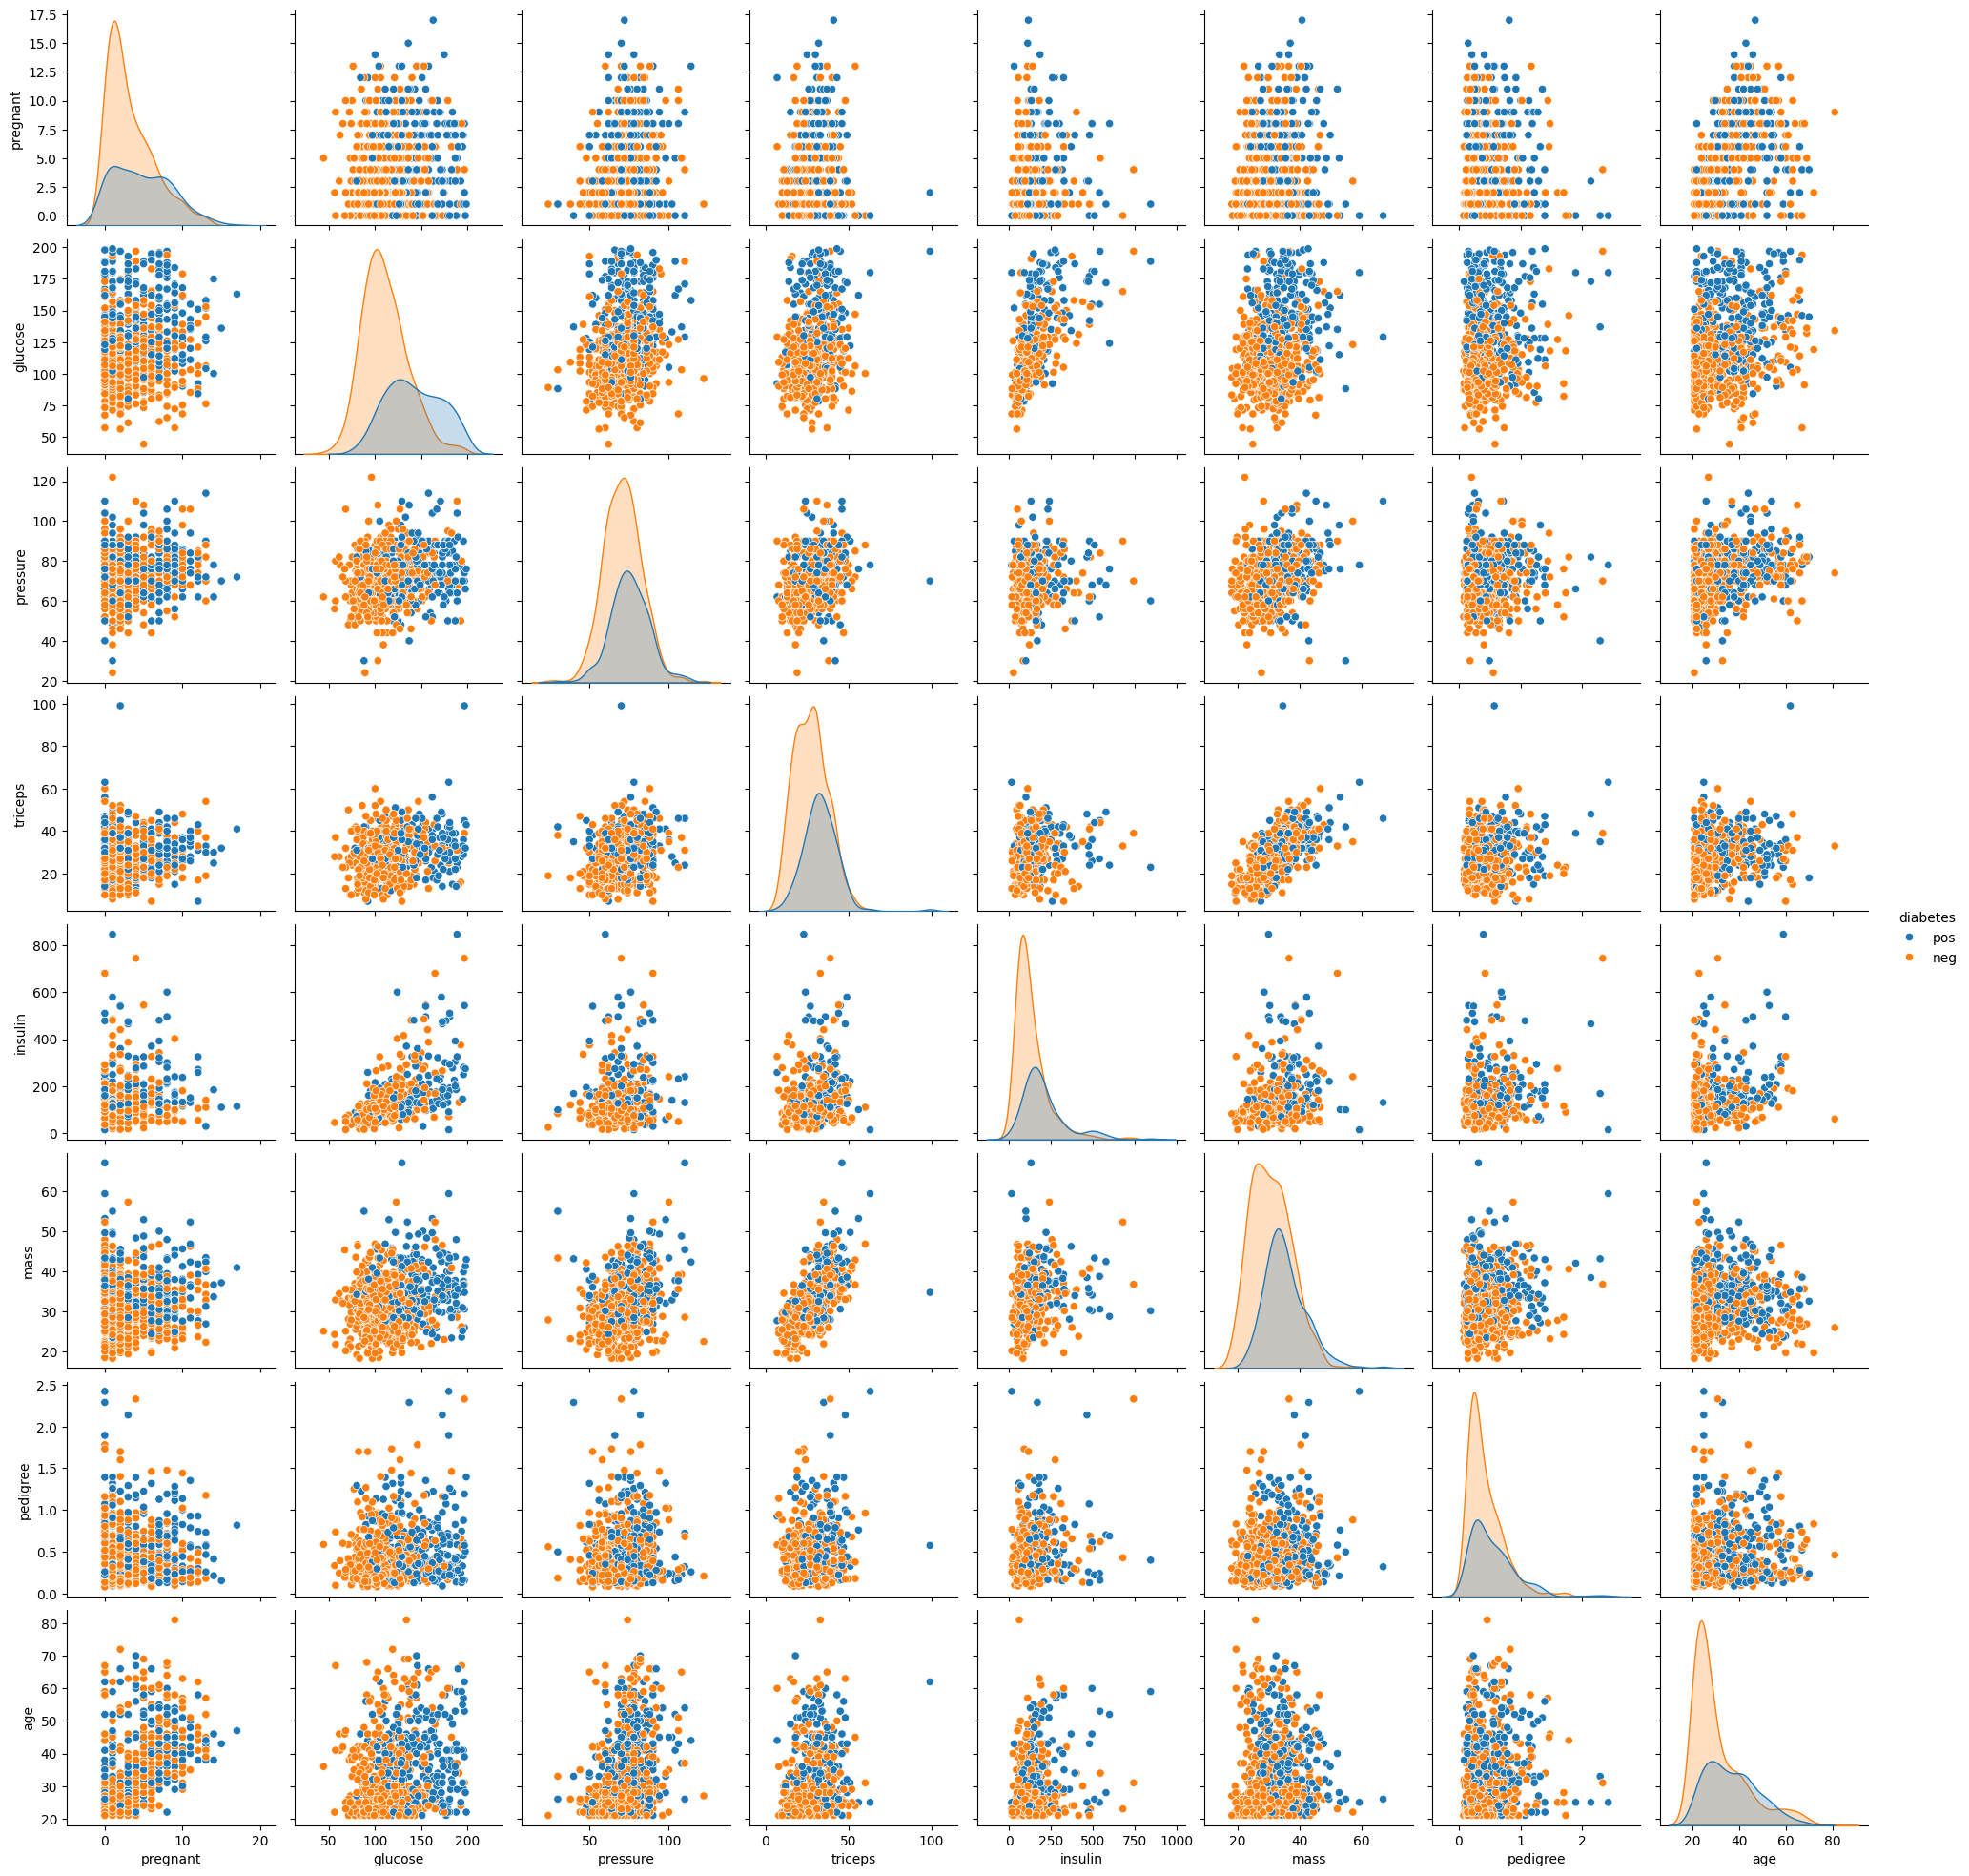

In [40]:
sns.pairplot(data=df,hue='diabetes')

In [42]:
features_df = df.drop('diabetes',axis=1)

In [65]:
features_df = features_df.fillna(features_df.median())
df[features_df.columns] = features_df

In [45]:
df

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
1,6,148.0,72.0,35.0,125.0,33.6,0.627,50,pos
2,1,85.0,66.0,29.0,125.0,26.6,0.351,31,neg
3,8,183.0,64.0,29.0,125.0,23.3,0.672,32,pos
4,1,89.0,66.0,23.0,94.0,28.1,0.167,21,neg
5,0,137.0,40.0,35.0,168.0,43.1,2.288,33,pos
...,...,...,...,...,...,...,...,...,...
764,10,101.0,76.0,48.0,180.0,32.9,0.171,63,neg
765,2,122.0,70.0,27.0,125.0,36.8,0.340,27,neg
766,5,121.0,72.0,23.0,112.0,26.2,0.245,30,neg
767,1,126.0,60.0,29.0,125.0,30.1,0.349,47,pos


In [46]:
df.isna().any()

pregnant    False
glucose     False
pressure    False
triceps     False
insulin     False
mass        False
pedigree    False
age         False
diabetes    False
dtype: bool

<Axes: xlabel='glucose'>

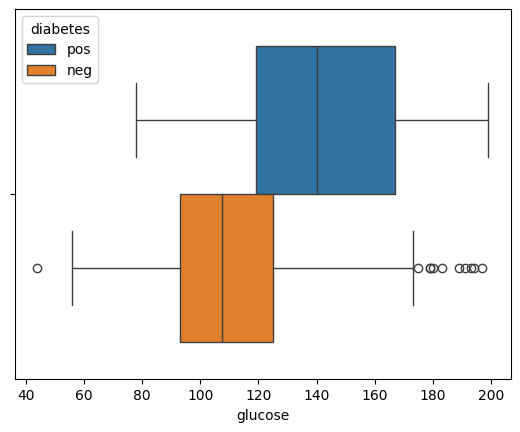

In [50]:
sns.boxplot(data=df,x='glucose',hue='diabetes')

<Axes: xlabel='mass'>

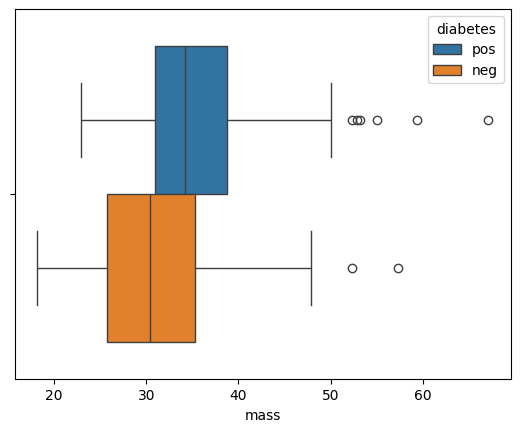

In [52]:
sns.boxplot(data=df,x='mass',hue='diabetes')

<Axes: xlabel='age'>

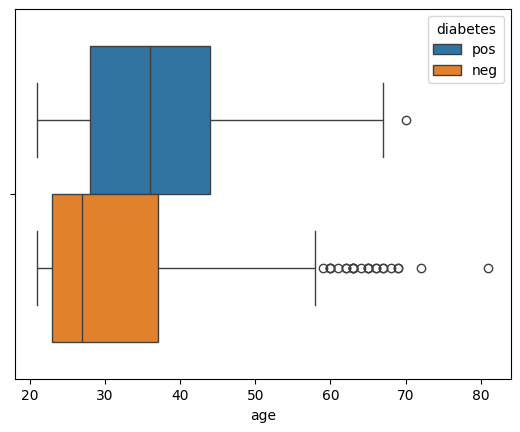

In [53]:
sns.boxplot(data=df,x='age',hue='diabetes')

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [ ]:
clf = LogisticRegression()

X = features_df.values
y = LabelEncoder().fit_transform(df.diabetes)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

from sklearn.metrics import ConfusionMatrixDisplay,classification_report

ConfusionMatrixDisplay.from_estimator(clf,X_test,y_test,normalize='true')
print(classification_report(y_test,y_pred))

from sklearn.metrics import RocCurveDisplay
# For ROC-AUC score, you need probability predictions
y_pred_proba = clf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC: {roc_auc}')
RocCurveDisplay.from_estimator(clf,X_test,y_test)

['neg' 'pos']
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        99
           1       0.68      0.62      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154

ROC-AUC: 0.7998163452708906


array([0.        , 0.59662493, 0.        , 0.        , 0.        ,
       0.26330515, 0.        , 0.14006992])

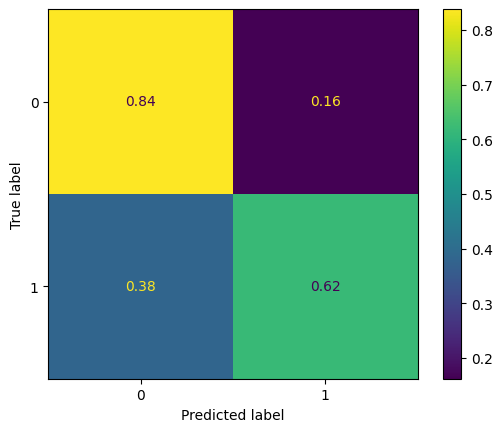

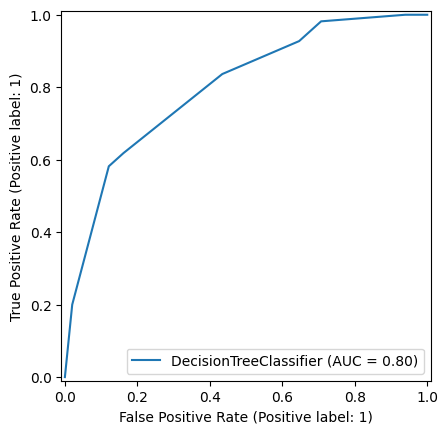

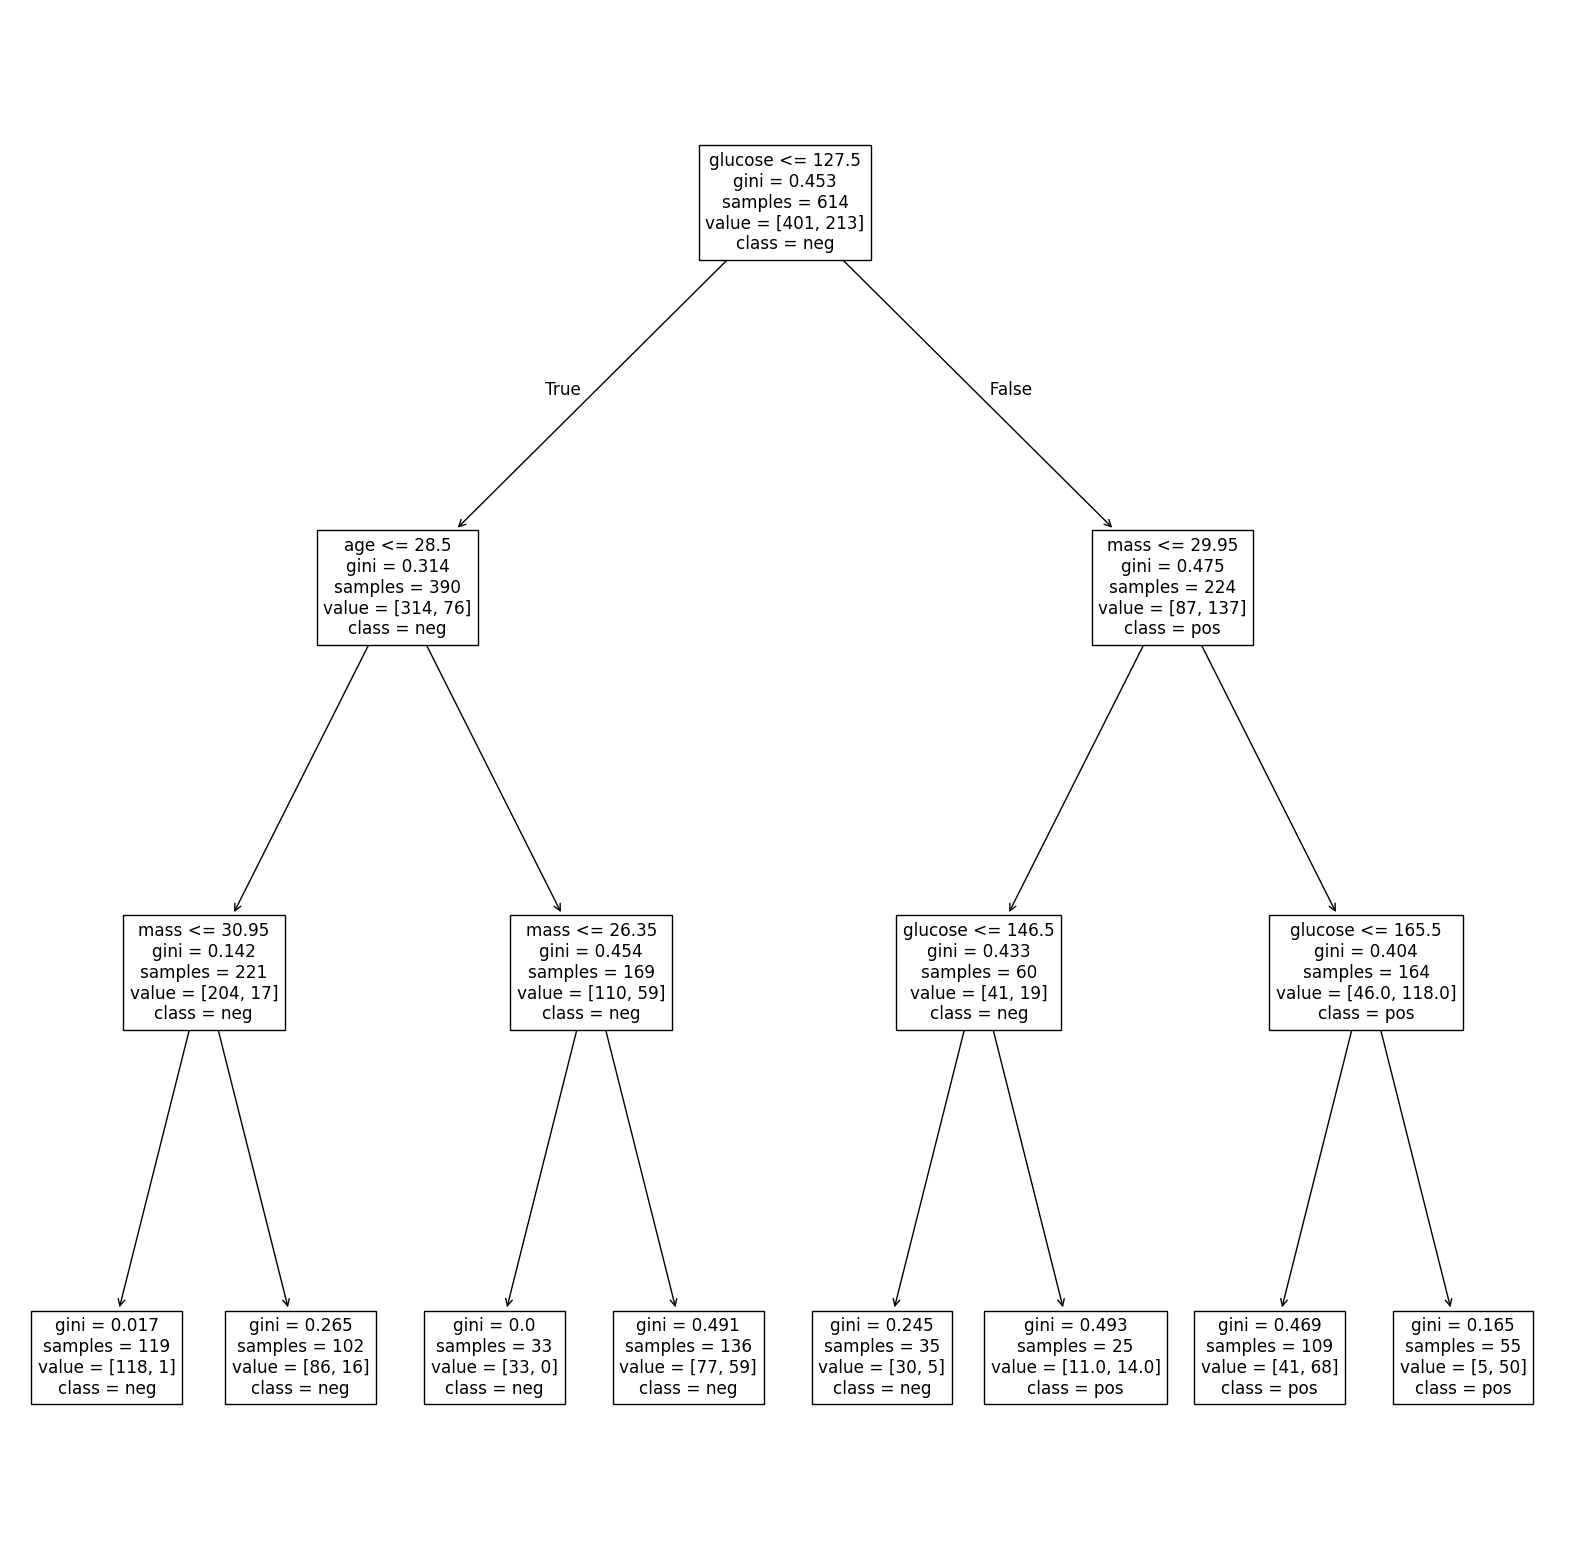

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
clf = DecisionTreeClassifier(max_depth=3)
X = features_df.values
enc = LabelEncoder()
y = enc.fit_transform(df.diabetes)
print(enc.classes_)
# Example: Load your dataset (replace with your actual dataset)
# X is the feature set and y is the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
ConfusionMatrixDisplay.from_estimator(clf,X_test,y_test,normalize='true')
print(classification_report(y_test,y_pred))

from sklearn.metrics import RocCurveDisplay
# For ROC-AUC score, you need probability predictions
y_pred_proba = clf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC: {roc_auc}')
RocCurveDisplay.from_estimator(clf,X_test,y_test)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,20))
plot_tree(clf,feature_names=features_df.columns,class_names=enc.classes_)
clf.feature_importances_

['neg' 'pos']
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

ROC-AUC: 0.837465564738292


array([0.07420795, 0.24957379, 0.08173864, 0.07776345, 0.09484377,
       0.15849329, 0.12352545, 0.13985366])

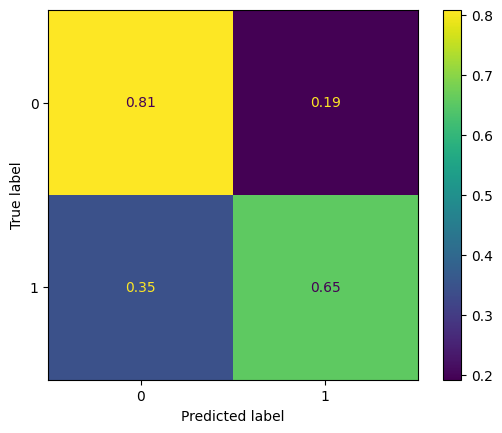

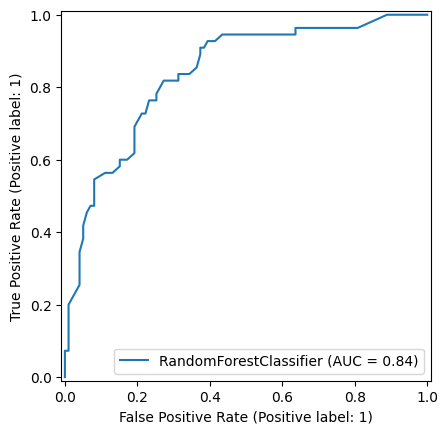

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
clf = RandomForestClassifier()
X = features_df.values
enc = LabelEncoder()
y = enc.fit_transform(df.diabetes)
print(enc.classes_)
# Example: Load your dataset (replace with your actual dataset)
# X is the feature set and y is the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
ConfusionMatrixDisplay.from_estimator(clf,X_test,y_test,normalize='true')
print(classification_report(y_test,y_pred))

from sklearn.metrics import RocCurveDisplay
# For ROC-AUC score, you need probability predictions
y_pred_proba = clf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC: {roc_auc}')
RocCurveDisplay.from_estimator(clf,X_test,y_test)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
clf.feature_importances_